<a href="https://colab.research.google.com/github/helonayala/sysid/blob/main/read_data_14_drone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1/4 drone data

This script reads the 1/4 drone data. The experiment is a sequence of steps in closed loop and data is used for building a nonlinear state space model.

First download data:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Install/import the sysid course library (works locally and on Google Colab) ---
try:
    from sysid import readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import readData

# Load our original 1/4 drone data (y, u, time, reference)
y, u, time, ref = readData("quarter_drone", "dados", return_ref=True)
tempo_s = time / 1000.0


Plot data

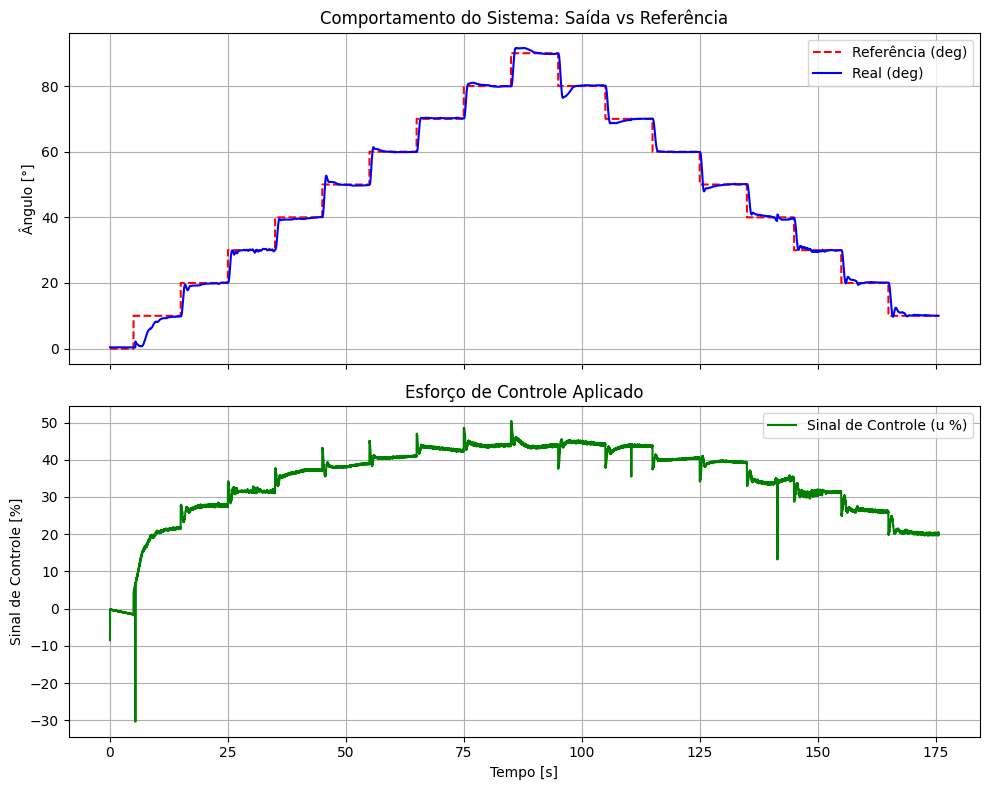

In [2]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Resposta do Sistema
ax1.plot(tempo_s, ref, label='Referência (deg)', linestyle='--', color='red')
ax1.plot(tempo_s, y, label='Real (deg)', color='blue')
ax1.set_ylabel('Ângulo [°]')
ax1.set_title('Comportamento do Sistema: Saída vs Referência')
ax1.legend()
ax1.grid(True)

# Esforço de Controle
ax2.plot(tempo_s, u, label='Sinal de Controle (u %)', color='green')
ax2.set_xlabel('Tempo [s]')
ax2.set_ylabel('Sinal de Controle [%]')
ax2.set_title('Esforço de Controle Aplicado')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## New closed-loop HIL datasets

Additional 1/4 drone acquisitions collected in closed loop (semi-static, steps, swept sine and multisine). Each is loaded with `readData("quarter_drone", <name>)`; for these the time vector is already in seconds (~100 Hz).

Semi-static (semi_estatica): 13001 samples


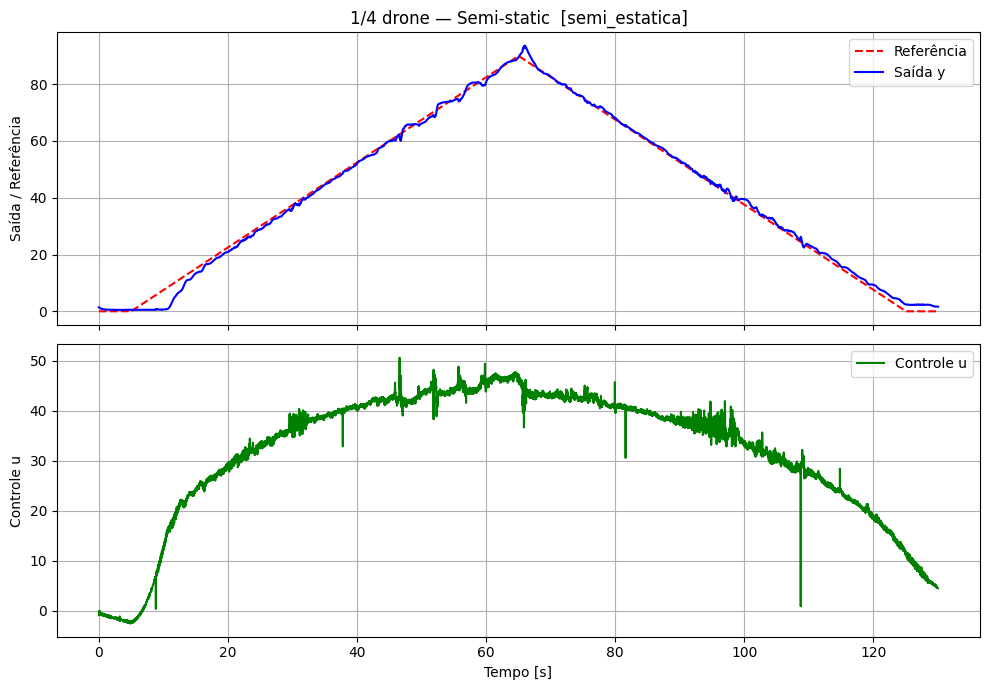

Steps (degraus): 10000 samples


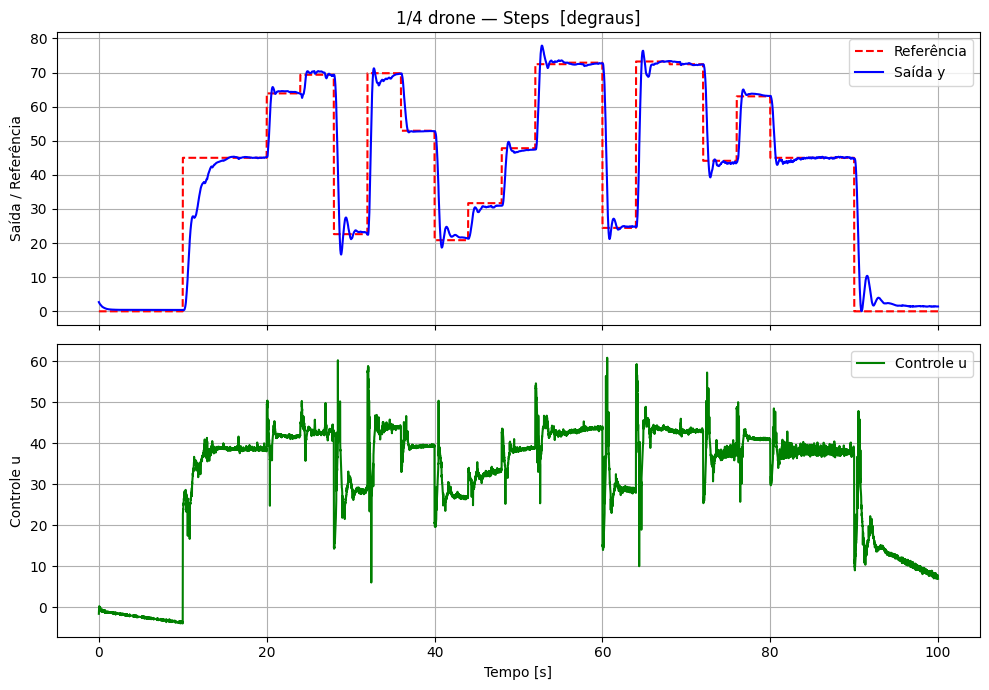

Swept sine (swept_sine): 10001 samples


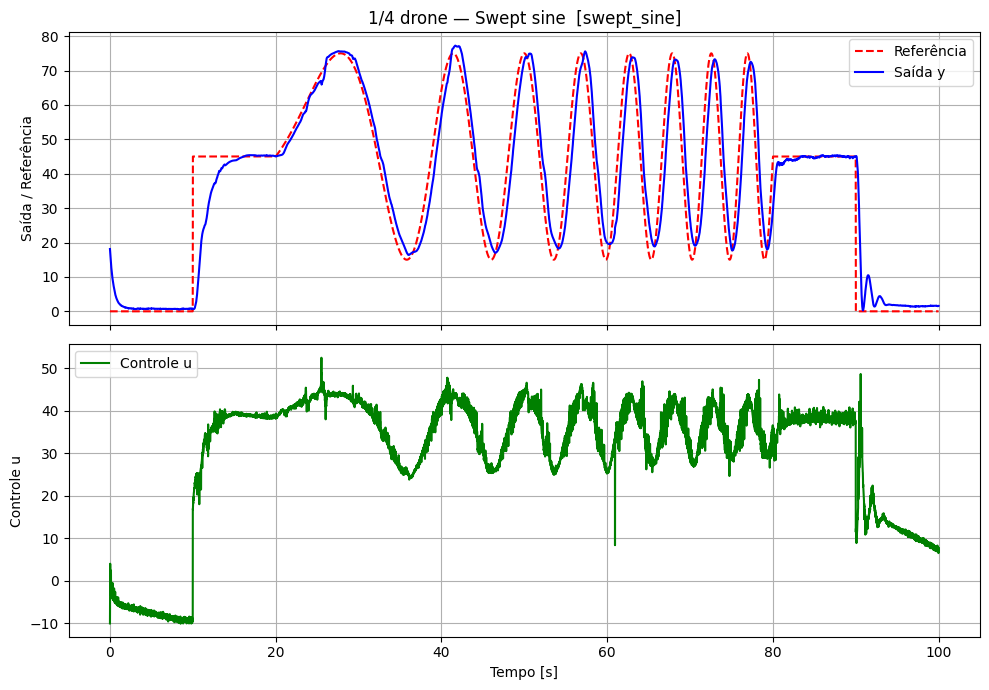

Multisine (multiseno): 10000 samples


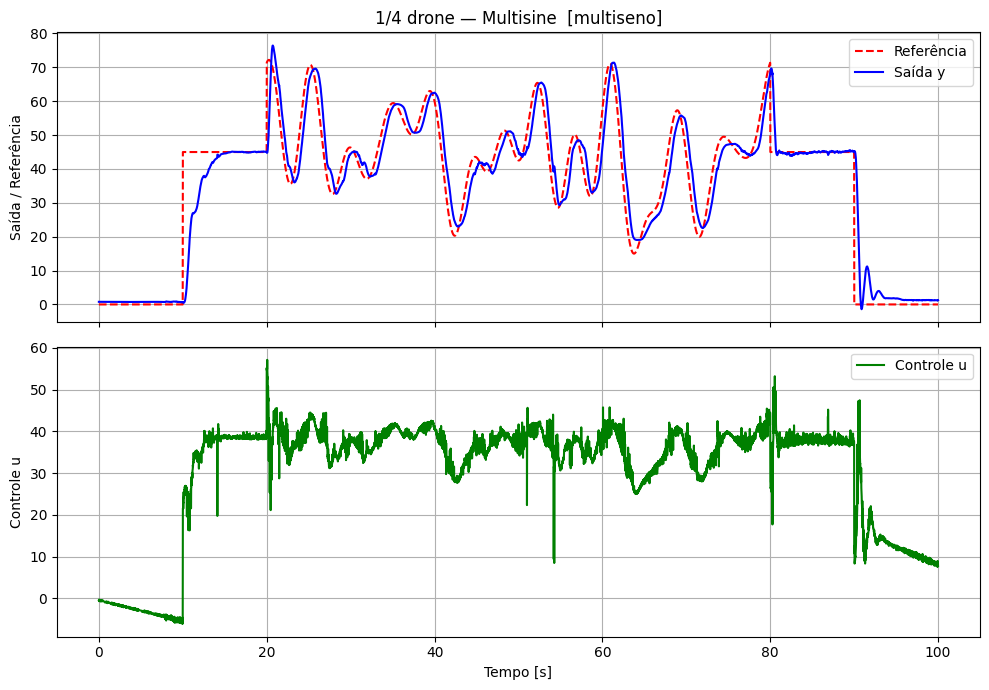

In [3]:
def plot_drone(y, u, time, ref, title):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    ax1.plot(time, ref, label='Referência', linestyle='--', color='red')
    ax1.plot(time, y, label='Saída y', color='blue')
    ax1.set_ylabel('Saída / Referência')
    ax1.set_title(title)
    ax1.legend(); ax1.grid(True)
    ax2.plot(time, u, label='Controle u', color='green')
    ax2.set_xlabel('Tempo [s]'); ax2.set_ylabel('Controle u')
    ax2.legend(); ax2.grid(True)
    plt.tight_layout(); plt.show()

datasets = {
    'semi_estatica': 'Semi-static',
    'degraus': 'Steps',
    'swept_sine': 'Swept sine',
    'multiseno': 'Multisine',
}
for name, label in datasets.items():
    y, u, time, ref = readData('quarter_drone', name, return_ref=True)
    print(f'{label} ({name}): {len(y)} samples')
    plot_drone(y, u, time, ref, f'1/4 drone — {label}  [{name}]')
